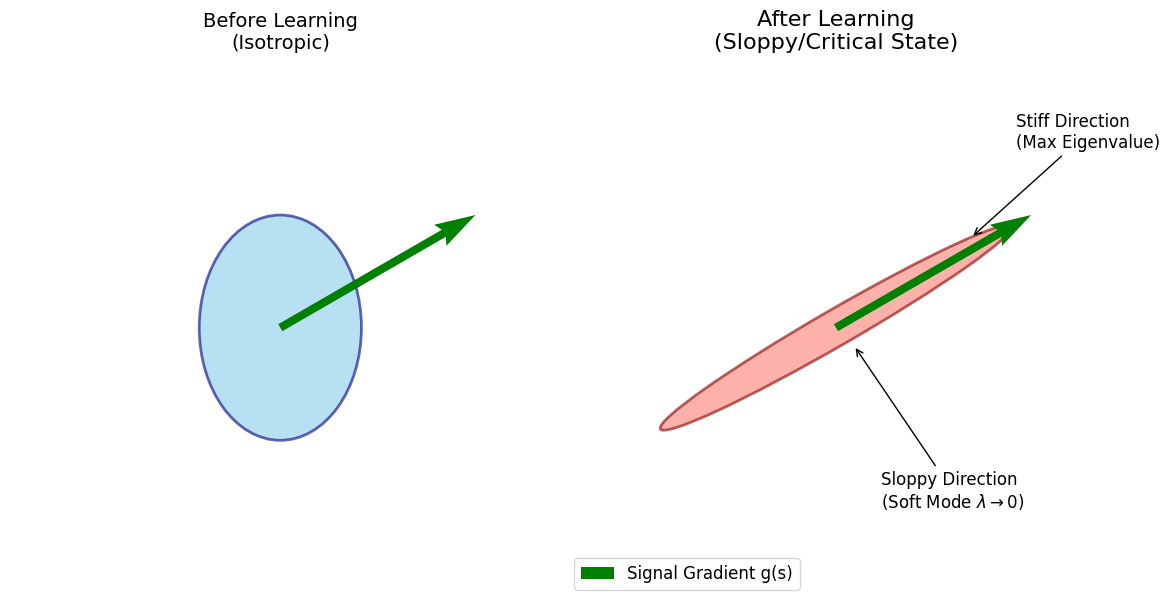

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def draw_model_schematic():
    fig, ax = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={'aspect': 'equal'})
    
    # Define stimulus gradient direction g(s) for visual reference
    g_angle = 30  # degrees
    g_vec = np.array([np.cos(np.radians(g_angle)), np.sin(np.radians(g_angle))])

    # --- Panel 1: Before Learning (Sub-critical, Isotropic) ---
    # A is close to an identity matrix; eigenvalues are similar
    width_pre, height_pre = 2.5, 1.8 
    angle_pre = 90
    
    ell_pre = Ellipse(xy=(0, 0), width=width_pre, height=height_pre, 
                      angle=angle_pre, edgecolor='navy', fc='skyblue', lw=2, alpha=0.6)
    ax[0].add_patch(ell_pre)
    ax[0].set_title("Before Learning\n(Isotropic)", fontsize=14)

    # --- Panel 2: After Learning (Critical, Sloppy) ---
    # A aligns with g(s); major axis expands (stiff), minor axis shrinks (sloppy/soft mode)
    width_post, height_post = 4.5, 0.4 
    angle_post = g_angle 
    
    ell_post = Ellipse(xy=(0, 0), width=width_post, height=height_post, 
                       angle=angle_post, edgecolor='darkred', fc='salmon', lw=2, alpha=0.6)
    ax[1].add_patch(ell_post)
    ax[1].set_title("After Learning\n(Sloppy/Critical State)", fontsize=16)

    # Add g(s) vector arrows for context
    for a in ax:
        a.quiver(0, 0, g_vec[0]*2.5, g_vec[1]*2.5, angles='xy', scale_units='xy', 
         scale=1, color='green', label='Signal Gradient g(s)', width=0.015)
        a.set_xlim(-3, 3)
        a.set_ylim(-3, 3)
        a.axis('off')
        
    # Annotate features
    ax[1].annotate('Stiff Direction\n(Max Eigenvalue)', xy=(1.5, 1.0), xytext=(2.0, 2.0),fontsize=12,
                   arrowprops=dict(arrowstyle='->', color='black'))
    ax[1].annotate('Sloppy Direction\n(Soft Mode $\lambda \\to 0$)', xy=(0.2, -0.2), xytext=(0.5, -2.0),fontsize=12,
                   arrowprops=dict(arrowstyle='->', color='black'))

    plt.tight_layout()
    plt.legend(fontsize=12,loc='lower left', ncol=1)
    plt.show()

if __name__ == "__main__":
    draw_model_schematic()


In [53]:
result_dir='result/'

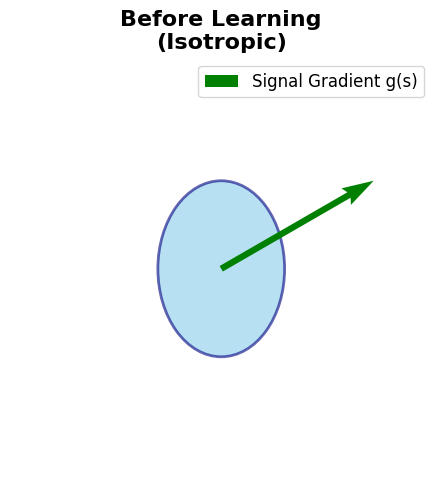

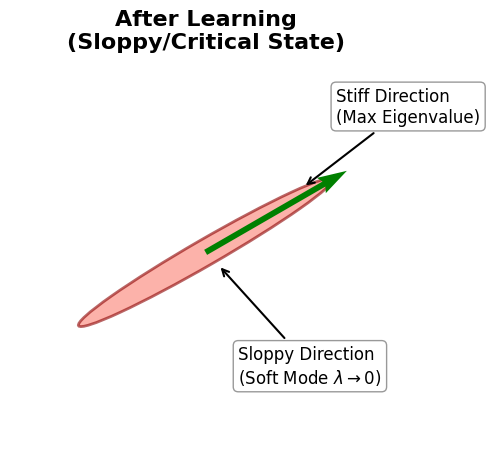

In [55]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

def draw_model_schematic():
    # Define stimulus gradient direction g(s) for visual reference
    g_angle = 30  # degrees
    g_vec = np.array([np.cos(np.radians(g_angle)), np.sin(np.radians(g_angle))])

    # --- Figure 1: Before Learning (Sub-critical, Isotropic) ---
    fig1, ax1 = plt.subplots(figsize=(5, 5), subplot_kw={'aspect': 'equal'})
    
    # A is close to an identity matrix; eigenvalues are similar
    width_pre, height_pre = 2.5, 1.8 
    angle_pre = 90
    
    ell_pre = Ellipse(xy=(0, 0), width=width_pre, height=height_pre, 
                      angle=angle_pre, edgecolor='navy', fc='skyblue', lw=2, alpha=0.6)
    ax1.add_patch(ell_pre)
    ax1.set_title("Before Learning\n(Isotropic)", fontsize=16, fontweight='bold')
    
    # Add g(s) vector arrow
    ax1.quiver(0, 0, g_vec[0]*2.5, g_vec[1]*2.5, angles='xy', scale_units='xy', 
               scale=1, color='green', label='Signal Gradient g(s)', width=0.015)
    
    ax1.set_xlim(-3, 3)
    ax1.set_ylim(-3, 3)
    ax1.axis('off')
    ax1.legend(fontsize=12, loc='upper right')
    
    plt.tight_layout()
    plt.savefig(result_dir+'before_learning.png',dpi=300)
    plt.show()

    # --- Figure 2: After Learning (Critical, Sloppy) ---
    fig2, ax2 = plt.subplots(figsize=(5, 5), subplot_kw={'aspect': 'equal'})
    
    # A aligns with g(s); major axis expands (stiff), minor axis shrinks (sloppy/soft mode)
    width_post, height_post = 4.5, 0.4 
    angle_post = g_angle 
    
    ell_post = Ellipse(xy=(0, 0), width=width_post, height=height_post, 
                       angle=angle_post, edgecolor='darkred', fc='salmon', lw=2, alpha=0.6)
    ax2.add_patch(ell_post)
    ax2.set_title("After Learning\n(Sloppy/Critical State)", fontsize=16, fontweight='bold')
    
    # Add g(s) vector arrow
    ax2.quiver(0, 0, g_vec[0]*2.5, g_vec[1]*2.5, angles='xy', scale_units='xy', 
               scale=1, color='green', label='Signal Gradient g(s)', width=0.015)
    
    # Annotate features
    ax2.annotate('Stiff Direction\n(Max Eigenvalue)', xy=(1.5, 1.0), xytext=(2.0, 2.0), fontsize=12,
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
    
    ax2.annotate('Sloppy Direction\n(Soft Mode $\\lambda \\to 0$)', xy=(0.2, -0.2), xytext=(0.5, -2.0), fontsize=12,
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
    
    ax2.set_xlim(-3, 3)
    ax2.set_ylim(-3, 3)
    ax2.axis('off')
    # ax2.legend(fontsize=12, loc='lower left')
    
    plt.tight_layout()
    plt.savefig(result_dir+'after_learning.png',dpi=300)
    plt.show()

if __name__ == "__main__":
    draw_model_schematic()

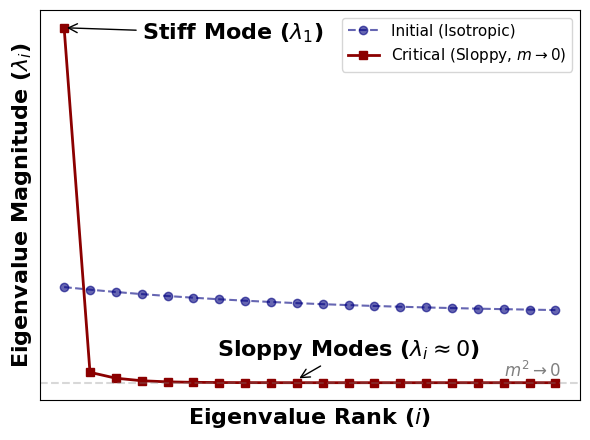

In [66]:
import numpy as np
import matplotlib.pyplot as plt

def draw_eigenvalue_condensation_simple():
    # Parameters
    N = 20  # Number of modes
    indices = np.arange(1, N + 1)

    # 1. Initial State: Relatively flat, high "mass" m^2
    # All eigenvalues are of similar magnitude
    m_initial = 1.2
    lambda_initial = m_initial + 0.5 * np.exp(-indices/10)

    # 2. Trained/Critical State: Lambda_1 >> others
    # Lambda_1 represents the "Stiff" direction aligned with g(s)
    # Others are "Sloppy" soft modes collapsing toward zero
    lambda_critical = np.zeros(N)
    lambda_critical[0] = 6.0  # Large stiff mode (Lambda 1)
    # Other modes follow a very sharp decay to a near-zero floor (m^2 -> 0)
    lambda_critical[1:] = 0.4 * np.exp(-(indices[1:]-1)/1.2) + 0.05

    # Plotting
    plt.figure(figsize=(6, 4.5))
    
    # Plot Initial State
    plt.plot(indices, lambda_initial, 'o--', color='navy', label='Initial (Isotropic)',alpha=0.6)
    
    # Plot Critical State
    plt.plot(indices, lambda_critical, 's-', color='darkred', label='Critical (Sloppy, $m \\to 0$)',lw=2)

    # Annotations for PRL style clarity
    plt.annotate(r'Stiff Mode ($\lambda_1$)', xy=(1, 6.0), xytext=(4, 5.8),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=16,fontweight='bold')
    
    plt.annotate(r'Sloppy Modes ($\lambda_i \approx 0$)', xy=(10, 0.1), xytext=(12, 0.5),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=16, fontweight='bold',ha='center')

    # Styling
    plt.xticks([])
    plt.yticks([])
    plt.xlabel('Eigenvalue Rank ($i$)', fontsize=16,fontweight='bold')
    plt.ylabel('Eigenvalue Magnitude ($\lambda_i$)', fontsize=16,fontweight='bold')
    # plt.title('Eigenvalue Condensation & Mode Separation', fontsize=15)
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.legend(fontsize=11)
    
    # Optional: Highlight the "floor" m^2
    plt.axhline(y=0.05, color='gray', linestyle='--', alpha=0.3)
    plt.text(N-2, 0.15, r'$m^2 \to 0$', color='gray', fontsize=12)

    plt.tight_layout()
    plt.savefig(result_dir+'eigenvalue.png',dpi=300)
    plt.show()

if __name__ == "__main__":
    draw_eigenvalue_condensation_simple()
